# **Experiment Notebook**



In [263]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [264]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [265]:
!pip uninstall -y my-krml-25942133

Found existing installation: my_krml_25942133 2025.0.1.3
Uninstalling my_krml_25942133-2025.0.1.3:
  Successfully uninstalled my_krml_25942133-2025.0.1.3


In [266]:
!pip install --index-url https://test.pypi.org/simple/ --no-deps my-krml-25942133==2025.0.1.3

Looking in indexes: https://test.pypi.org/simple/
  Using cached https://test-files.pythonhosted.org/packages/22/11/e4b2d6f7bf194d45ee7248cd1602a0f551e97b752d73aede25a944a61211/my_krml_25942133-2025.0.1.3-py3-none-any.whl.metadata (1.4 kB)
Using cached https://test-files.pythonhosted.org/packages/22/11/e4b2d6f7bf194d45ee7248cd1602a0f551e97b752d73aede25a944a61211/my_krml_25942133-2025.0.1.3-py3-none-any.whl (23 kB)



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [267]:
import my_krml_25942133
print(my_krml_25942133.__version__)


2025.0.1.3


In [268]:
%matplotlib inline

In [269]:
# <Student to fill this section>
import requests
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from my_krml_25942133.data.sets import separate_columns
from my_krml_25942133.data.api import fetch_api_to_csv
from my_krml_25942133.features.heatmap import plot_correlation_matrix
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

---
## A. Project Description


In [270]:
# <Student to fill this section>
student_name = "Kankshi Shah"
student_id = "25942133"
group_id = "30"

In [271]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [272]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [273]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [274]:
# <Student to fill this section>
business_use_case_description = """
From a business perspective, the goal of this project is to develop a data product that attracts and retains cryptocurrency investors by providing them with meaningful insights and predictive analytics. By offering real-time market data and AI-driven forecasts, the platform positions the business as a trusted provider of intelligent financial tools, helping users make evidence-based investment decisions. This strengthens the company’s credibility in the fintech and data analytics domain while differentiating it from competitors who rely on generic data displays without predictive capabilities.

The project also serves as a strategic foundation for future growth and monetization. Once user engagement increases, the business can expand the platform to include premium features such as personalized investment recommendations, portfolio management tools, and advanced analytics dashboards. In the long term, this creates opportunities for subscription-based revenue models, data partnerships, and brand recognition within the growing digital finance market.
"""

In [275]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [276]:
# <Student to fill this section>
business_objectives = """
Accurate results from the platform can build user trust and credibility, encouraging investors to rely on the app for informed decisions. Reliable historical data and precise ML-based predictions can enhance user engagement, promote positive word-of-mouth, and position the business as a trusted authority in cryptocurrency analytics, supporting long-term growth and potential monetization opportunities.

On the other hand, incorrect results can undermine user confidence and damage the business’s reputation. Inaccurate predictions may lead to financial losses for users, causing dissatisfaction and decreased engagement. Over time, repeated inaccuracies can limit growth, reduce adoption of premium features, and make it challenging to establish the platform as a dependable investment tool in a competitive market.
"""

In [277]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [278]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The results from the platform, including historical data insights and next-day high price predictions, will be used by investors to inform their cryptocurrency trading and investment decisions. Users can analyze trends, assess potential risks, and plan their buy or sell actions based on both historical patterns and predictive forecasts, making their investment strategies more data-driven and proactive.

The primary users of these predictions will be individual investors and traders interested in Bitcoin, Ethereum, XRP, and Solana. Indirectly, anyone whose decisions depend on cryptocurrency market movements, such as portfolio managers, financial advisors, and fintech platforms integrating these insights, may also be impacted. Accurate predictions can help them optimize investment outcomes, while inaccurate predictions could lead to financial losses or suboptimal decisions.
"""

In [279]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [280]:
# <Student to fill this section>
# List of file paths i want to use to merge into one solana_df
files = [
    r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\Solana\Solana_01_01_2024-01_01_2025_historical_data_coinmarketcap.csv",
    r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\Solana\Solana_01_01_2020-01_01_2021_historical_data_coinmarketcap.csv",
    r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\Solana\Solana_01_01_2021-01_01_2022_historical_data_coinmarketcap.csv",
    r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\Solana\Solana_01_01_2022-01_01_2023_historical_data_coinmarketcap.csv",
    r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\Solana\Solana_01_01_2023-01_01_2024_historical_data_coinmarketcap.csv"
]
dfs = [pd.read_csv(f, sep=';') for f in files]

# Creating a consolidated df from 2020 - 2025
solana_df = pd.concat(dfs, ignore_index=True)

# Convert timestamp column to datetime
solana_df['timestamp'] = pd.to_datetime(solana_df['timestamp'], errors='coerce')
solana_df = solana_df.sort_values('timestamp').reset_index(drop=True)

In [281]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [282]:
solana_df.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp
0,2020-04-11T00:00:00.000Z,2020-04-11T23:59:59.999Z,2020-04-11T04:06:03.000Z,2020-04-11T23:54:19.000Z,2781,0.951054,1.049073,0.765020,0.776819,43862443.79,0.0,2020-04-11 23:59:59.999000+00:00
1,2020-04-12T00:00:00.000Z,2020-04-12T23:59:59.999Z,2020-04-12T21:29:10.000Z,2020-04-12T00:41:17.000Z,2781,0.785448,0.956670,0.762426,0.882507,38736897.02,0.0,2020-04-12 23:59:59.999000+00:00
2,2020-04-13T00:00:00.000Z,2020-04-13T23:59:59.999Z,2020-04-13T00:02:14.000Z,2020-04-13T23:44:07.000Z,2781,0.890760,0.891603,0.773976,0.777832,18211285.47,0.0,2020-04-13 23:59:59.999000+00:00
3,2020-04-14T00:00:00.000Z,2020-04-14T23:59:59.999Z,2020-04-14T02:16:12.000Z,2020-04-14T21:38:18.000Z,2781,0.777832,0.796472,0.628169,0.661925,16747614.12,0.0,2020-04-14 23:59:59.999000+00:00
4,2020-04-15T00:00:00.000Z,2020-04-15T23:59:59.999Z,2020-04-15T03:45:04.000Z,2020-04-15T16:03:17.000Z,2781,0.669289,0.704964,0.621531,0.646651,13075275.29,0.0,2020-04-15 23:59:59.999000+00:00


In [283]:
solana_df.columns

Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high',
       'low', 'close', 'volume', 'marketCap', 'timestamp'],
      dtype='object')

In [284]:
solana_df.shape

(1726, 12)

In [285]:
import my_krml_25942133.data.api
print(my_krml_25942133.__file__)


C:\Users\KANKSHI SHAH\AppData\Local\Programs\Python\Python313\Lib\site-packages\my_krml_25942133\__init__.py


In [286]:
url = "https://api.kraken.com/0/public/OHLC?pair=SOLUSD&interval=60"
save_path = r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\solana_test.csv"

# Fetch only the latest row from the last 24 hours
test_df, path = fetch_api_to_csv(
    url=url,
    save_path=save_path,
    latest_only=True,
    since_hours=24
)

Data saved at: C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\solana_test.csv


In [287]:
test_df.head()

,time,open,high,low,close,vwap,volume,count
23,2025-11-03 10:00:00,174.89,175.88,174.5,174.91,175.16,4031.657008,472


In [288]:
import requests
import pandas as pd
from datetime import datetime

# --- Fetch OHLC data (test_df) ---
# Example: assuming you already have test_df from Kraken
# test_df has columns: ['time', 'open', 'high', 'low', 'close', 'vwap', 'volume', 'count']

# ---Fetch latest market cap from CoinGecko ---
url = "https://api.coingecko.com/api/v3/coins/solana/market_chart"
params = {"vs_currency": "usd", "days": 1}

response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

# Convert market_caps to DataFrame
market_caps = pd.DataFrame(data["market_caps"], columns=["timestamp", "market_cap"])
market_caps["time"] = pd.to_datetime(market_caps["timestamp"], unit="ms")
market_caps = market_caps[["time", "market_cap"]]

# Keep only the latest market cap entry
latest_marketcap = market_caps.iloc[[-1]]

# ---Add market_cap to test_df ---
test_df = test_df.copy()
test_df["market_cap"] = latest_marketcap["market_cap"].values[0]

# --- Save the updated DataFrame ---
save_path = r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\solana_test_df.csv"
test_df.to_csv(save_path, index=False)
print(f"Updated dataset saved at: {save_path}")

Updated dataset saved at: C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data\solana_test_df.csv


In [289]:
test_df.head()

,time,open,high,low,close,vwap,volume,count,market_cap
23,2025-11-03 10:00:00,174.89,175.88,174.5,174.91,175.16,4031.657008,472,9.659157e+10


### C.2 Define Target variable

In [290]:
# <Student to fill this section>
solana_df['high_next_day'] = solana_df['high'].shift(-1)
solana_df = solana_df[:-1]

In [291]:
solana_df.shape

(1725, 13)

In [292]:
solana_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   timeOpen       1725 non-null   object             
 1   timeClose      1725 non-null   object             
 2   timeHigh       1725 non-null   object             
 3   timeLow        1725 non-null   object             
 4   name           1725 non-null   int64              
 5   open           1725 non-null   float64            
 6   high           1725 non-null   float64            
 7   low            1725 non-null   float64            
 8   close          1725 non-null   float64            
 9   volume         1725 non-null   float64            
 10  marketCap      1725 non-null   float64            
 11  timestamp      1725 non-null   datetime64[ns, UTC]
 12  high_next_day  1725 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(7), int64(1),

In [293]:
# <Student to fill this section>
target_definition_explanations = """
The target variable high_next_day represents the predicted highest price of the selected cryptocurrency for the following day. This aligns with the business use case of providing investors with actionable insights, enabling them to anticipate price peaks and make informed trading decisions. By forecasting the next day’s high, the model supports short-term investment strategies, risk management, and timing of buy/sell actions, which is critical for maximizing returns in the volatile cryptocurrency market.
"""

In [294]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [295]:
# <Student to fill this section>

target_name = 'high_next_day'

### C.4 Explore Target variable

In [296]:
# <Student to fill this section>
solana_df[target_name].describe()

count    1725.000000
mean       71.322739
std        70.371626
min         0.559759
25%        18.146622
50%        35.899520
75%       135.997818
max       263.831546
Name: high_next_day, dtype: float64

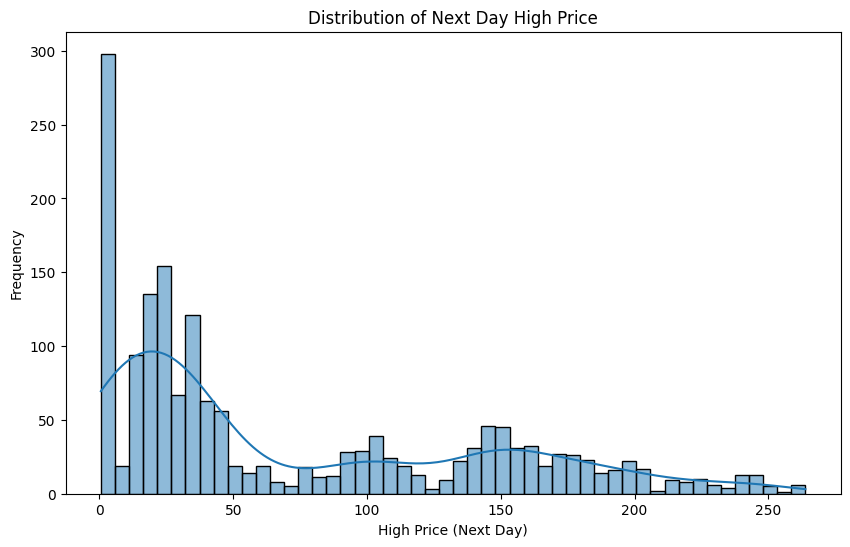

In [297]:
# Visualising the distribution across the variable
plt.figure(figsize=(10,6))
sns.histplot(solana_df['high_next_day'].dropna(), bins=50, kde=True)
plt.title("Distribution of Next Day High Price")
plt.xlabel("High Price (Next Day)")
plt.ylabel("Frequency")
plt.show()

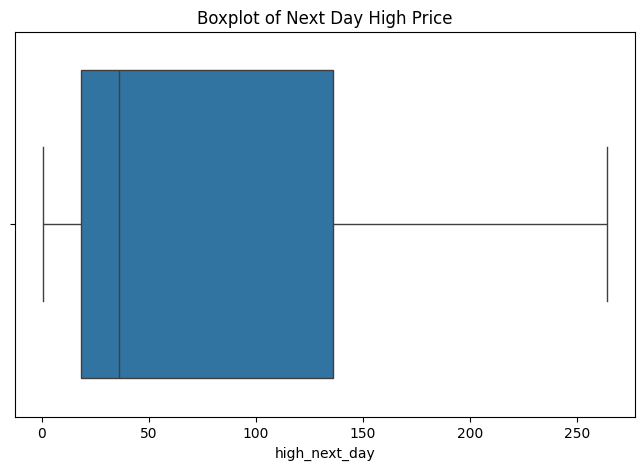

In [298]:
# Visualising for outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=solana_df['high_next_day'].dropna())
plt.title("Boxplot of Next Day High Price")
plt.show()

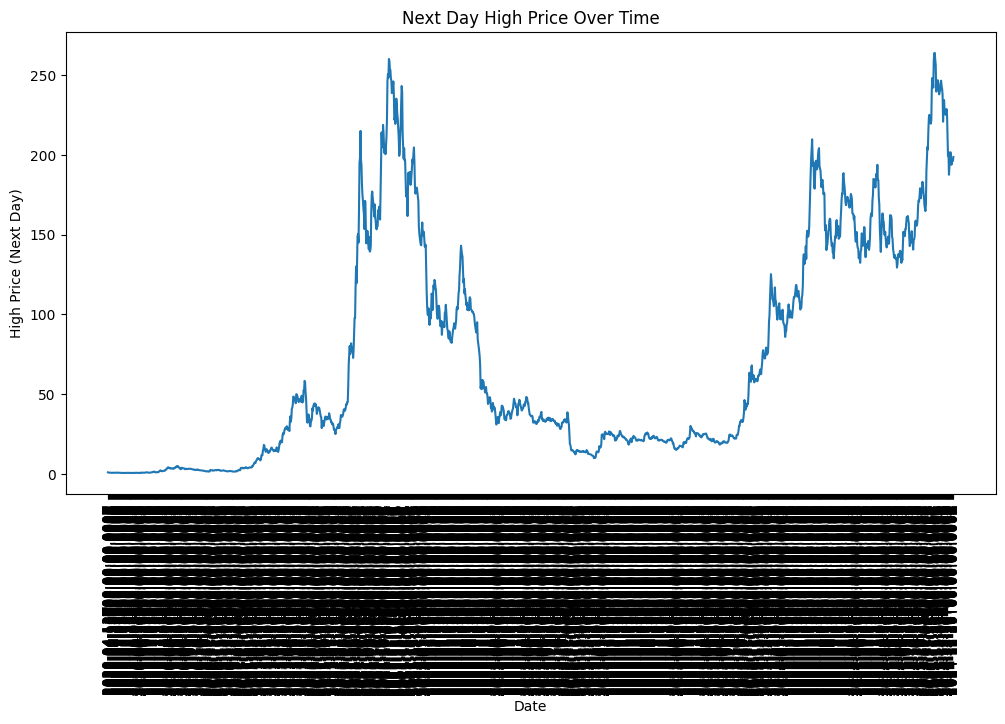

In [299]:
# Visualising Trend over time
plt.figure(figsize=(12,6))
plt.plot(solana_df['timeOpen'], solana_df['high_next_day'])
plt.title("Next Day High Price Over Time")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("High Price (Next Day)")
plt.show()

In [300]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable, high_next_day, represents the predicted high price of Solana for the next trading day. Its summary statistics show a mean of approximately 71.32 with a standard deviation of 70.37, which indicates a very high variability relative to the mean. The minimum value is 0.56, and the maximum value is 263.83, showing that the dataset includes both very low and extremely high values. The 25th, 50th, and 75th percentiles are 18.15, 35.90, and 136.0, respectively, suggesting a right-skewed distribution where a significant portion of high prices is concentrated at the lower range, but there are occasional extreme spikes. This skewness and high variance are typical for cryptocurrency prices, which are highly volatile and influenced by market dynamics, news, and speculation.
"""

In [301]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `volume`

In [302]:
# <Student to fill this section>

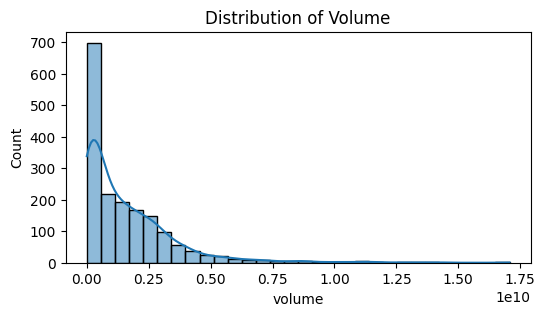

In [303]:
plt.figure(figsize=(6,3))
sns.histplot(solana_df['volume'], kde=True, bins=30)
plt.title('Distribution of Volume')
plt.show()

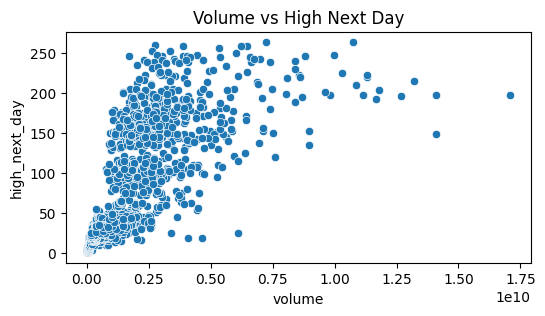

In [304]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=solana_df['volume'], y=solana_df['high_next_day'])
plt.title('Volume vs High Next Day')
plt.show()

In [305]:
solana_df['volume'].describe()

count    1.725000e+03
mean     1.573839e+09
std      1.896914e+09
min      6.520201e+05
25%      2.476409e+08
50%      9.885913e+08
75%      2.334408e+09
max      1.706864e+10
Name: volume, dtype: float64

In [306]:
# <Student to fill this section>
feature_1_insights = """
The volume feature represents the total trading volume of Solana during each time interval. From the summary statistics, it is evident that volume is highly skewed, with a mean of approximately 1.57 billion and extreme outliers reaching up to 17 billion, while the minimum is only around 0.65 million. The distribution shows that most observations are concentrated in the lower ranges, with a long tail of exceptionally high trading volumes. Visualizations suggest that volume is inversely proportional to high_next_day, meaning that days with unusually high trading activity do not necessarily correspond to higher next-day prices. This could indicate that large sell-offs or buy-ins create temporary volatility without sustaining upward price movement.

Despite its potential importance, the volume feature has several limitations. First, the extreme skewness and presence of outliers can distort statistical relationships and model assumptions if not handled properly. Log transformations or scaling may be necessary to normalize its impact. Second, while volume can indicate market sentiment, it does not fully capture the direction of price movement or market manipulation, which may confound predictive models. Finally, the inverse relationship with the target highlights that high trading activity alone may not be a reliable predictor of the next day's high, and combining volume with other derived features, such as price trends or volatility measures, is essential for meaningful insights.
"""

In [307]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `marketCap`

In [308]:
# <Student to fill this section>

In [309]:
solana_df['marketCap'].describe()

count    1.725000e+03
mean     2.670936e+10
std      2.880762e+10
min      0.000000e+00
25%      6.250327e+09
50%      1.153485e+10
75%      4.599502e+10
max      1.220065e+11
Name: marketCap, dtype: float64

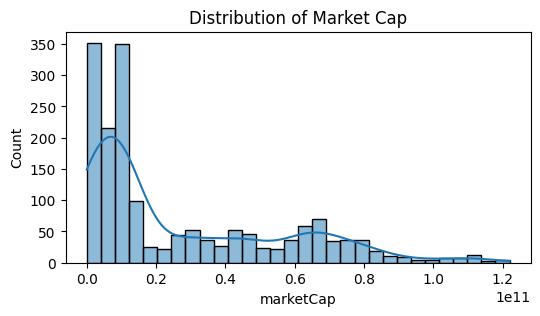

In [310]:
plt.figure(figsize=(6,3))
sns.histplot(solana_df['marketCap'], kde=True, bins=30)
plt.title('Distribution of Market Cap')
plt.show()

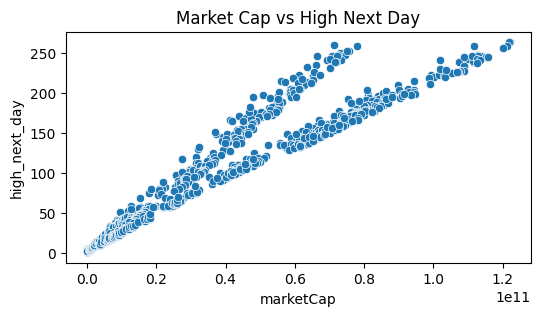

In [311]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=solana_df['marketCap'], y=solana_df['high_next_day'])
plt.title('Market Cap vs High Next Day')
plt.show()

In [312]:
num_cols , cat_cols = separate_columns(solana_df)

In [313]:
num_cols.remove(target_name)

(           name      open      high       low     close    volume  marketCap
 name        NaN       NaN       NaN       NaN       NaN       NaN        NaN
 open        NaN  1.000000  0.998826  0.998470  0.997472  0.743117   0.965149
 high        NaN  0.998826  1.000000  0.998161  0.999014  0.756636   0.964436
 low         NaN  0.998470  0.998161  1.000000  0.998600  0.729650   0.968978
 close       NaN  0.997472  0.999014  0.998600  1.000000  0.747244   0.967603
 volume      NaN  0.743117  0.756636  0.729650  0.747244  1.000000   0.746261
 marketCap   NaN  0.965149  0.964436  0.968978  0.967603  0.746261   1.000000,
 <Axes: title={'center': 'Correlation Matrix'}>,
 <Figure size 1000x800 with 2 Axes>)

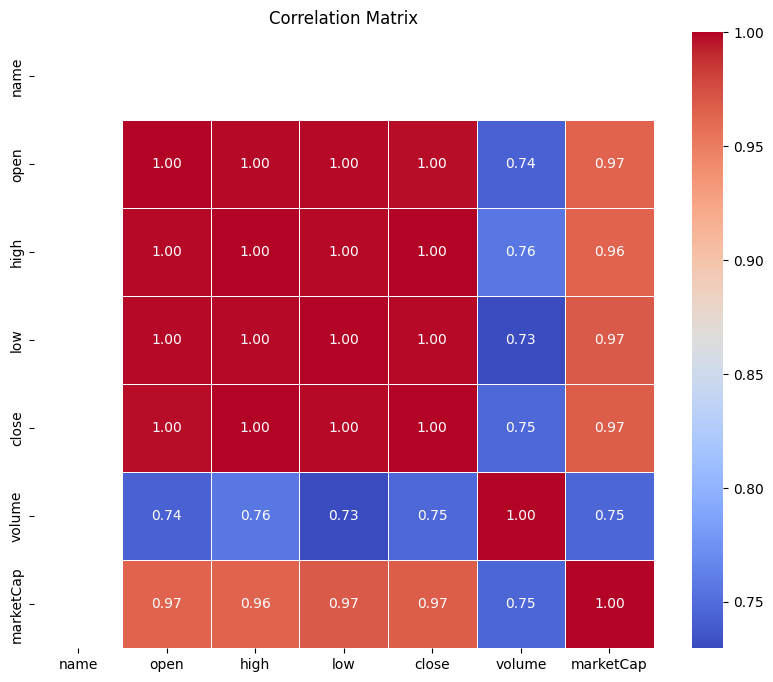

In [314]:
plot_correlation_matrix(solana_df, num_cols)

In [316]:
# <Student to fill this section>
feature_2_insights = """
The marketCap feature represents the total market value of Solana’s circulating supply within a given time interval. It shows a wide range — from 0 to over 122 billion — indicating significant fluctuations in Solana’s valuation over time. The mean market capitalization (~26.7 billion) and high standard deviation suggest that the data is highly skewed, likely with a few extreme peaks during market booms. Such variance can make it difficult for models to capture trends effectively without normalization or transformation. The quartile distribution also reveals that most values lie in the lower range, confirming the presence of heavy right-skewness typical in volatile cryptocurrency markets.

From a correlation perspective, marketCap exhibits very strong positive correlations with the open, high, low, and close prices (all > 0.96), which is expected since market capitalization is derived directly from price and circulating supply. This multicollinearity indicates redundancy — including all these variables in a model could inflate variance and reduce interpretability. Furthermore, the strong relationship suggests that marketCap may not add much independent predictive power. Careful feature selection or dimensionality reduction (e.g., PCA or removing redundant variables) might be necessary to ensure stable and meaningful predictions.
"""

In [317]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `timeHigh`


In [318]:
# <Student to fill this section>

In [319]:
solana_df.describe(include='object')

,timeOpen,timeClose,timeHigh,timeLow
count,1725,1725,1725,1725
unique,1725,1725,1725,1724
top,2020-04-11T00:00:00.000Z,2020-04-11T23:59:59.999Z,2020-04-11T04:06:03.000Z,2022-09-14T00:07:00.000Z
freq,1,1,1,2


In [320]:
solana_df['timeHigh'].describe(include='object')

count                         1725
unique                        1725
top       2020-04-11T04:06:03.000Z
freq                             1
Name: timeHigh, dtype: object

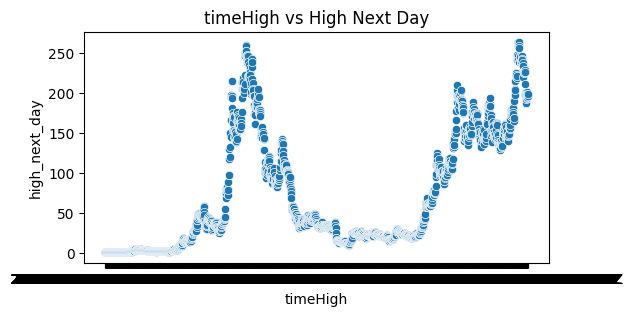

In [321]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=solana_df['timeHigh'], y=solana_df['high_next_day'])
plt.title('timeHigh vs High Next Day')
plt.show()

In [322]:
# <Student to fill this section>
feature_n_insights = """
The feature timeHigh represents the exact timestamp when the highest price was recorded for each trading period. It contains 1,725 unique ISO-format UTC timestamps, indicating no duplicates and consistent time tracking. The plotted trend shows clear cyclical price peaks, suggesting periods of market volatility and possible seasonality. However, being time-based, it cannot be directly used in correlation analysis without transformation. Key limitations include irregular intervals, timezone sensitivity, and non-numeric format. To make it useful, it should be converted to datetime and decomposed into components such as hour, day, or month to capture temporal trading patterns and improve predictive modeling.
"""

In [323]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.n Explore Feature of Interest `name`

> You can add more cells related to other feeatures in this section

In [324]:
solana_df['name'].unique()

array([2781])

Dropping the column **`name`** because it contains only a **single unique value (2781)** across all records, meaning it provides **no variability or useful information** for the model to learn from.

---
## D. Feature Selection


### D.1 Approach "Correlation Analysis"


In [325]:
# <Student to fill this section>

Before Feature Selection I need to fix the featuers before using it ahead.

In [326]:
df = solana_df.copy()

In [327]:
solana_df['timeOpen'] = pd.to_datetime(solana_df['timeOpen'])
solana_df['timeClose'] = pd.to_datetime(solana_df['timeClose'])
solana_df['timeHigh'] = pd.to_datetime(solana_df['timeHigh'])
solana_df['timeLow'] = pd.to_datetime(solana_df['timeLow'])

In [328]:
for col in ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']:
    solana_df[f'{col}_hour'] = solana_df[col].dt.hour
    solana_df[f'{col}_day'] = solana_df[col].dt.day
    solana_df[f'{col}_month'] = solana_df[col].dt.month
    solana_df[f'{col}_year'] = solana_df[col].dt.year
    solana_df[f'{col}_weekday'] = solana_df[col].dt.weekday  # 0=Mon, 6=Sun


In [329]:
solana_df.columns

Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high',
       'low', 'close', 'volume', 'marketCap', 'timestamp', 'high_next_day',
       'timeOpen_hour', 'timeOpen_day', 'timeOpen_month', 'timeOpen_year',
       'timeOpen_weekday', 'timeClose_hour', 'timeClose_day',
       'timeClose_month', 'timeClose_year', 'timeClose_weekday',
       'timeHigh_hour', 'timeHigh_day', 'timeHigh_month', 'timeHigh_year',
       'timeHigh_weekday', 'timeLow_hour', 'timeLow_day', 'timeLow_month',
       'timeLow_year', 'timeLow_weekday'],
      dtype='object')

In [330]:
solana_df.shape

(1725, 33)

In [331]:
solana_df.head(20)

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp,high_next_day,timeOpen_hour,timeOpen_day,timeOpen_month,timeOpen_year,timeOpen_weekday,timeClose_hour,timeClose_day,timeClose_month,timeClose_year,timeClose_weekday,timeHigh_hour,timeHigh_day,timeHigh_month,timeHigh_year,timeHigh_weekday,timeLow_hour,timeLow_day,timeLow_month,timeLow_year,timeLow_weekday
0,2020-04-11 00:00:00+00:00,2020-04-11 23:59:59.999000+00:00,2020-04-11 04:06:03+00:00,2020-04-11 23:54:19+00:00,2781,0.951054,1.049073,0.765020,0.776819,43862443.79,0.0,2020-04-11 23:59:59.999000+00:00,0.956670,0,11,4,2020,5,23,11,4,2020,5,4,11,4,2020,5,23,11,4,2020,5
1,2020-04-12 00:00:00+00:00,2020-04-12 23:59:59.999000+00:00,2020-04-12 21:29:10+00:00,2020-04-12 00:41:17+00:00,2781,0.785448,0.956670,0.762426,0.882507,38736897.02,0.0,2020-04-12 23:59:59.999000+00:00,0.891603,0,12,4,2020,6,23,12,4,2020,6,21,12,4,2020,6,0,12,4,2020,6
2,2020-04-13 00:00:00+00:00,2020-04-13 23:59:59.999000+00:00,2020-04-13 00:02:14+00:00,2020-04-13 23:44:07+00:00,2781,0.890760,0.891603,0.773976,0.777832,18211285.47,0.0,2020-04-13 23:59:59.999000+00:00,0.796472,0,13,4,2020,0,23,13,4,2020,0,0,13,4,2020,0,23,13,4,2020,0
3,2020-04-14 00:00:00+00:00,2020-04-14 23:59:59.999000+00:00,2020-04-14 02:16:12+00:00,2020-04-14 21:38:18+00:00,2781,0.777832,0.796472,0.628169,0.661925,16747614.12,0.0,2020-04-14 23:59:59.999000+00:00,0.704964,0,14,4,2020,1,23,14,4,2020,1,2,14,4,2020,1,21,14,4,2020,1
4,2020-04-15 00:00:00+00:00,2020-04-15 23:59:59.999000+00:00,2020-04-15 03:45:04+00:00,2020-04-15 16:03:17+00:00,2781,0.669289,0.704964,0.621531,0.646651,13075275.29,0.0,2020-04-15 23:59:59.999000+00:00,0.774192,0,15,4,2020,2,23,15,4,2020,2,3,15,4,2020,2,16,15,4,2020,2
5,2020-04-16 00:00:00+00:00,2020-04-16 23:59:59.999000+00:00,2020-04-16 07:43:17+00:00,2020-04-16 00:20:19+00:00,2781,0.630879,0.774192,0.625107,0.690816,21346031.35,0.0,2020-04-16 23:59:59.999000+00:00,0.719614,0,16,4,2020,3,23,16,4,2020,3,7,16,4,2020,3,0,16,4,2020,3
6,2020-04-17 00:00:00+00:00,2020-04-17 23:59:59.999000+00:00,2020-04-17 02:10:18+00:00,2020-04-17 23:59:17+00:00,2781,0.689312,0.719614,0.660728,0.660728,9870810.00,0.0,2020-04-17 23:59:59.999000+00:00,0.717618,0,17,4,2020,4,23,17,4,2020,4,2,17,4,2020,4,23,17,4,2020,4
7,2020-04-18 00:00:00+00:00,2020-04-18 23:59:59.999000+00:00,2020-04-18 14:49:09+00:00,2020-04-18 00:17:13+00:00,2781,0.660728,0.717618,0.659427,0.681096,9782111.90,0.0,2020-04-18 23:59:59.999000+00:00,0.684641,0,18,4,2020,5,23,18,4,2020,5,14,18,4,2020,5,0,18,4,2020,5
8,2020-04-19 00:00:00+00:00,2020-04-19 23:59:59.999000+00:00,2020-04-19 00:13:15+00:00,2020-04-19 16:40:16+00:00,2781,0.681516,0.684641,0.598487,0.606969,9289670.38,0.0,2020-04-19 23:59:59.999000+00:00,0.639254,0,19,4,2020,6,23,19,4,2020,6,0,19,4,2020,6,16,19,4,2020,6
9,2020-04-20 00:00:00+00:00,2020-04-20 23:59:59.999000+00:00,2020-04-20 09:37:11+00:00,2020-04-20 20:07:11+00:00,2781,0.612948,0.639254,0.520578,0.538812,8342616.42,0.0,2020-04-20 23:59:59.999000+00:00,0.604586,0,20,4,2020,0,23,20,4,2020,0,9,20,4,2020,0,20,20,4,2020,0


Exploring the new features added to know what needs to be fixed before feature selection.

In [332]:
solana_df['timeOpen_hour'].unique()

array([0], dtype=int32)

Dropping the column **`timeOpen_hour`** because it contains only a **single unique value (0)** across all records, meaning it provides **no variability or useful information** for the model to learn from.

In [333]:
solana_df['timeClose_hour'].unique()

array([23], dtype=int32)

Dropping the column **`timeOpen_hour`** because it contains only a **single unique value (23)** across all records, meaning it provides **no variability or useful information** for the model to learn from.

In [334]:
# Drop original datetime columns after feature extraction and redundant features as well
solana_df = solana_df.drop(columns=['timeOpen', 'timeClose', 'timeHigh', 'timeLow','timestamp','name','timeClose_hour','timeOpen_hour'])

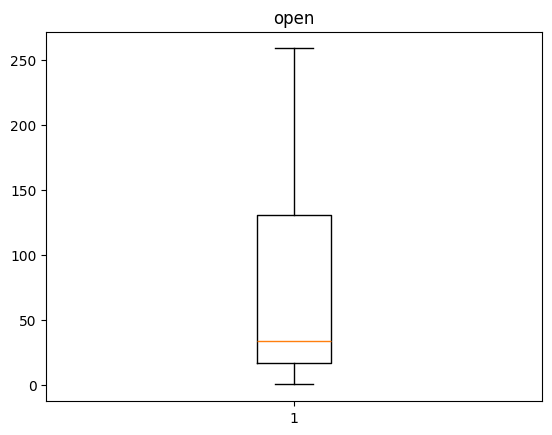

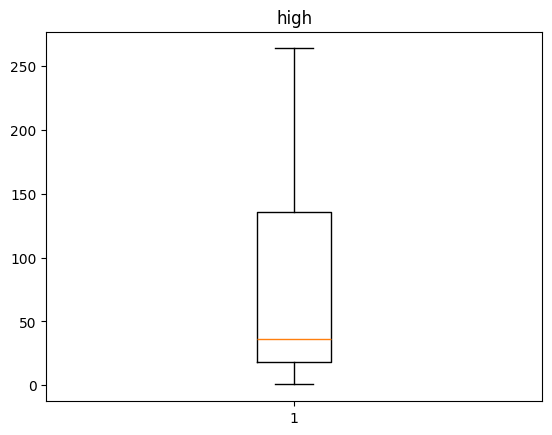

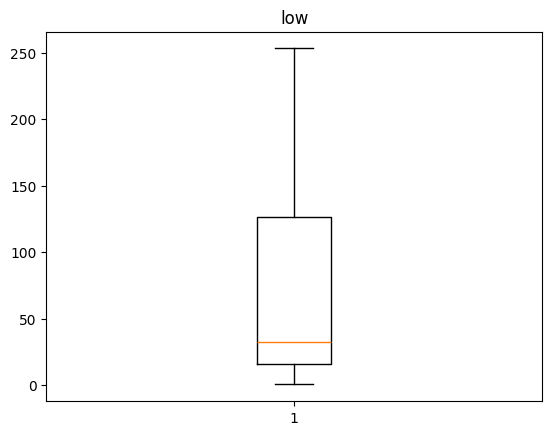

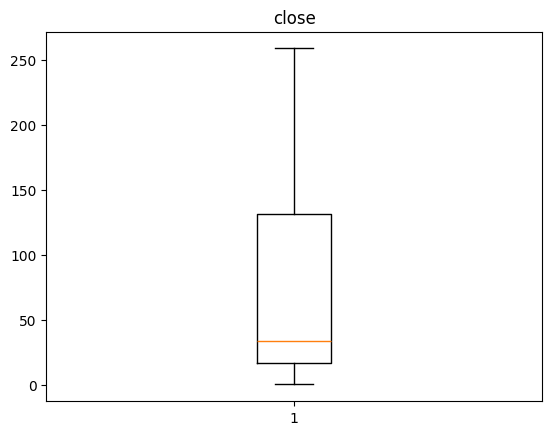

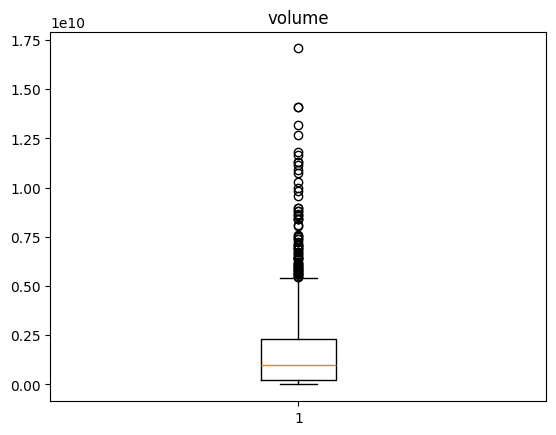

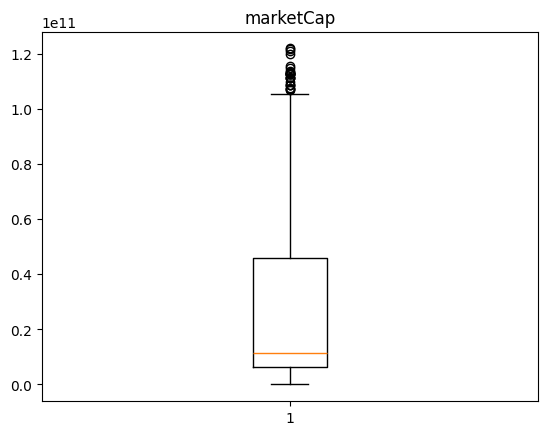

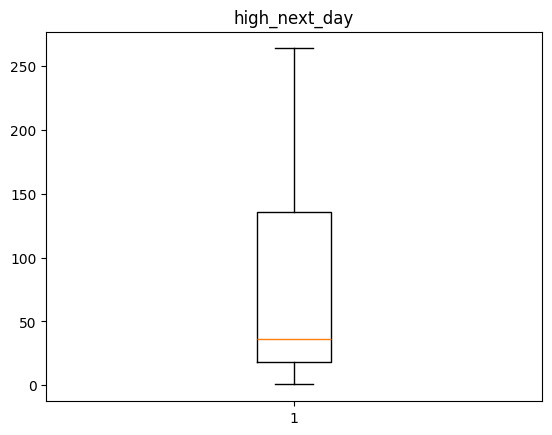

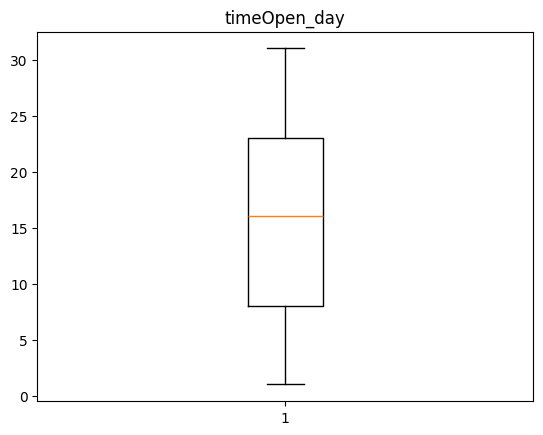

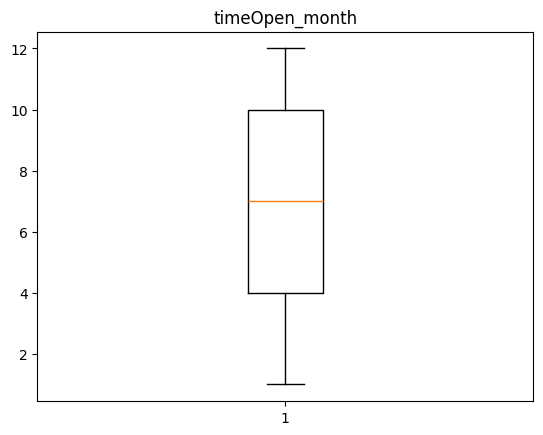

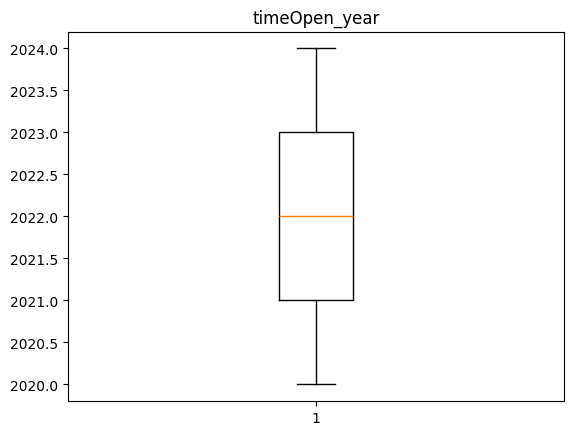

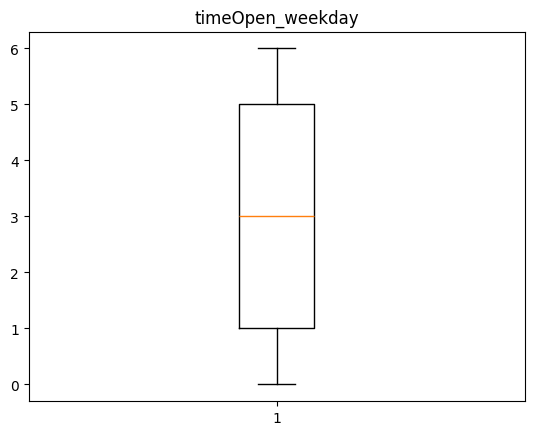

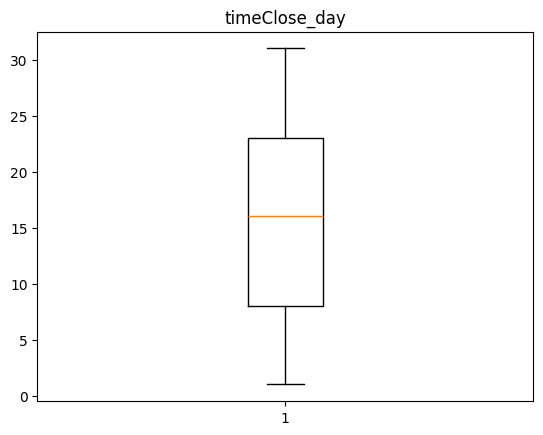

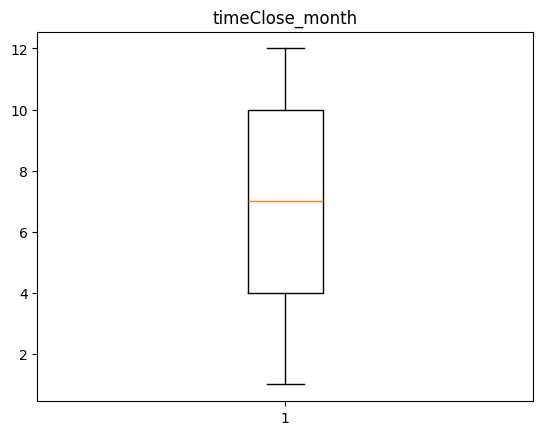

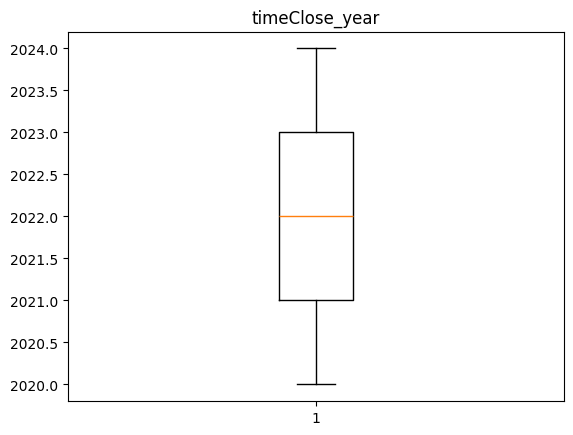

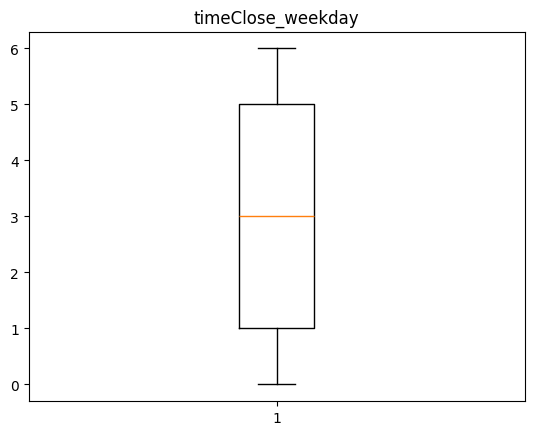

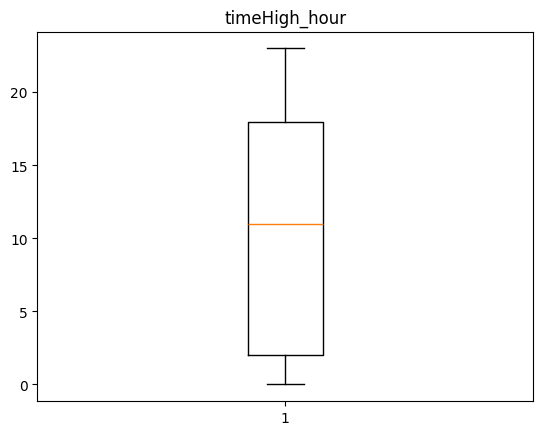

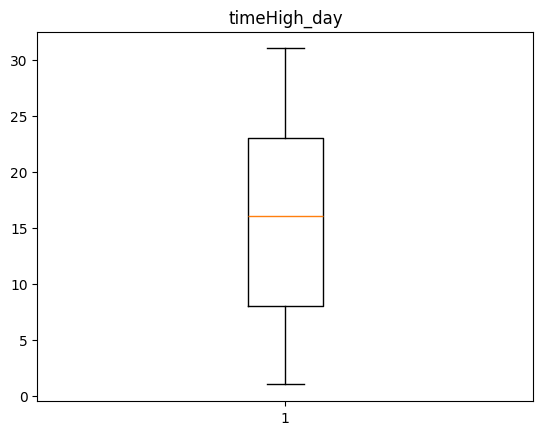

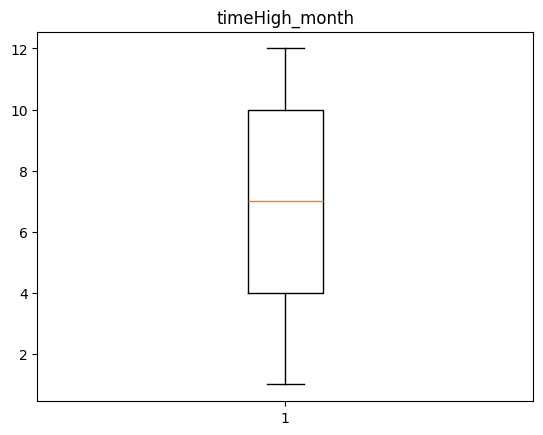

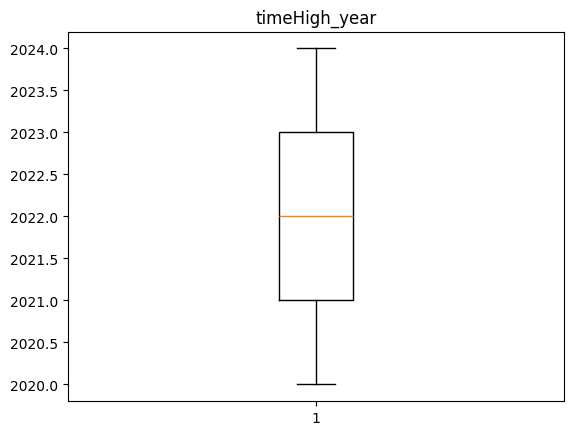

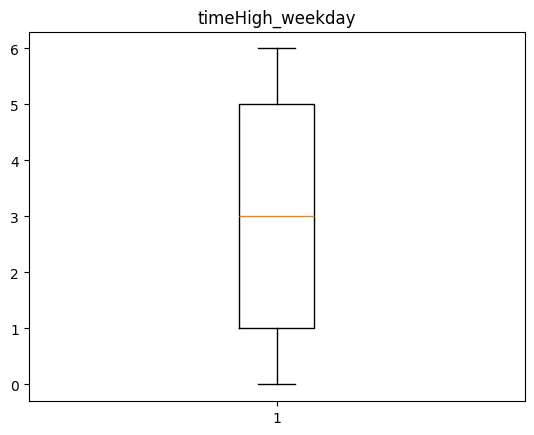

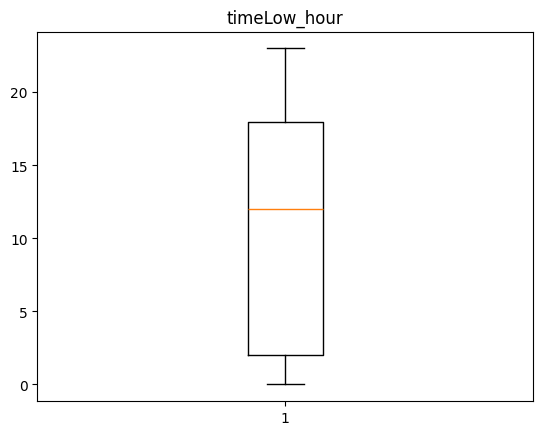

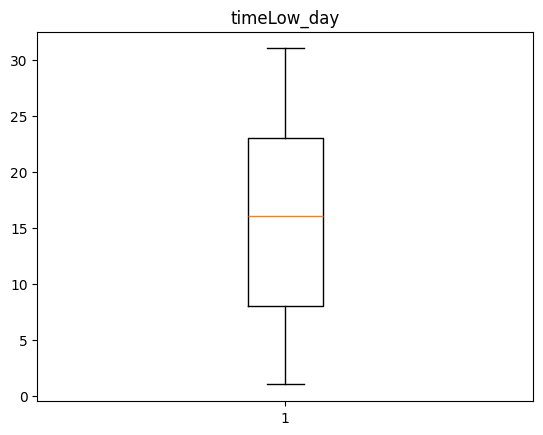

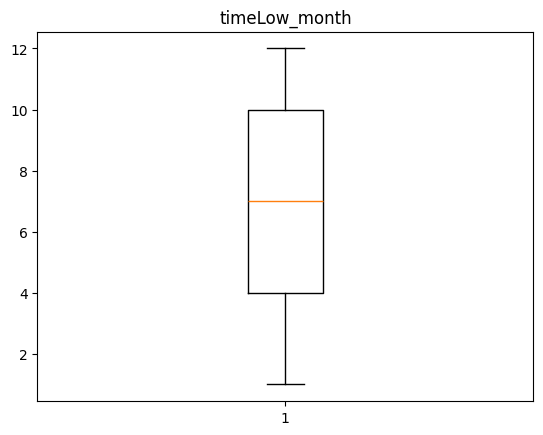

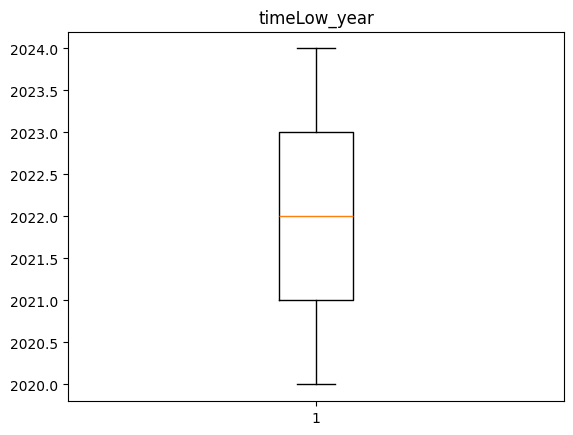

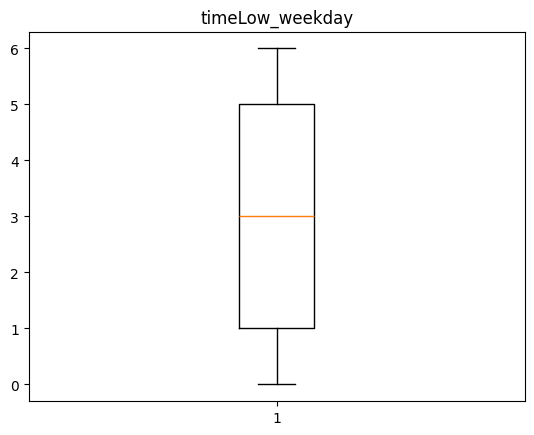

In [335]:
for i in solana_df.columns:
    plt.boxplot(solana_df[i])
    plt.title(i)
    plt.show()

The columns **marketCap** and **volume** have outliers but since the data is a crypto data having extreme values can be meaningful for the model to learn from and any tree based algorithm is robust to outliers so leaving thoses columns as it is would make sense.

In [336]:
solana_df.isnull().sum()

open                 0
high                 0
low                  0
close                0
volume               0
marketCap            0
high_next_day        0
timeOpen_day         0
timeOpen_month       0
timeOpen_year        0
timeOpen_weekday     0
timeClose_day        0
timeClose_month      0
timeClose_year       0
timeClose_weekday    0
timeHigh_hour        0
timeHigh_day         0
timeHigh_month       0
timeHigh_year        0
timeHigh_weekday     0
timeLow_hour         0
timeLow_day          0
timeLow_month        0
timeLow_year         0
timeLow_weekday      0
dtype: int64

In [337]:
solana_df.duplicated().sum()

np.int64(0)

Performing Correlation Analysis on the clean data now

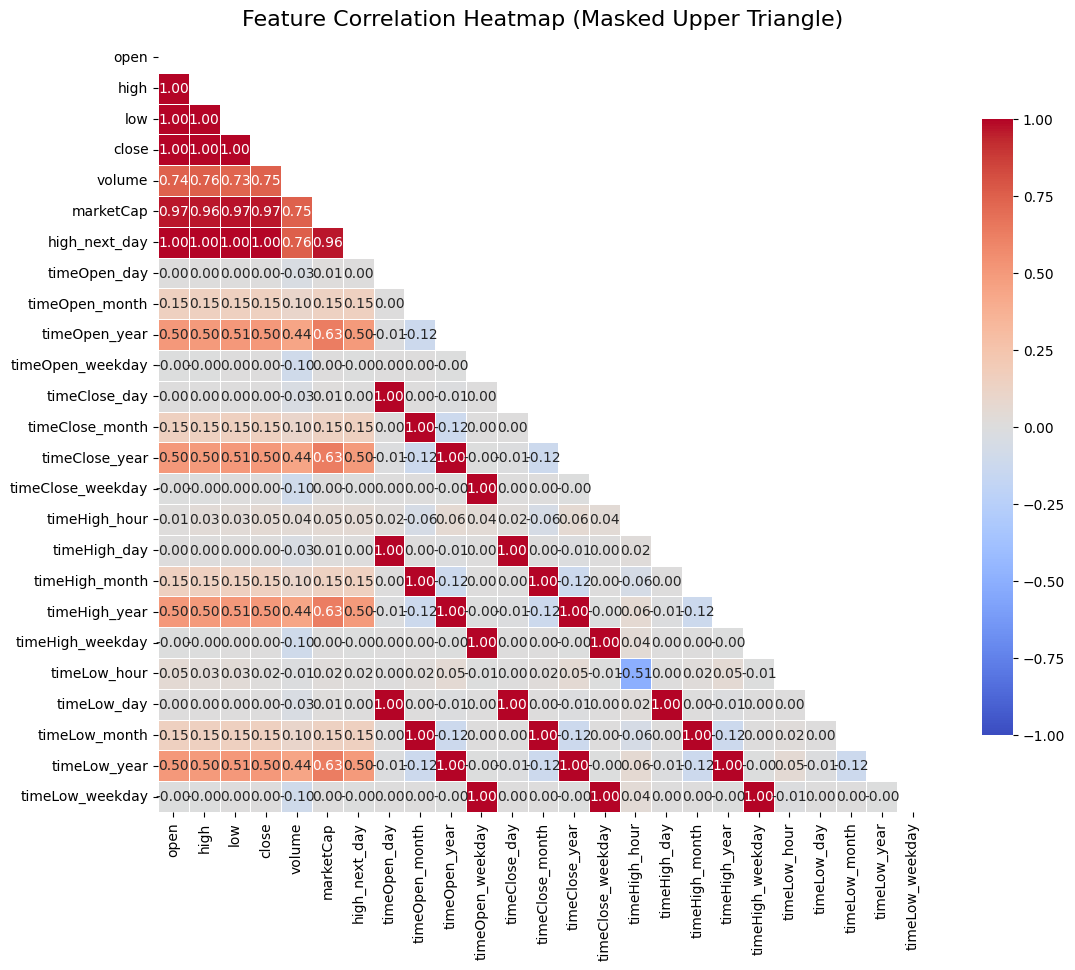


Top correlations with 'high_next_day':

high_next_day        1.000000
close                0.998795
high                 0.998246
low                  0.996788
open                 0.996164
marketCap            0.964363
volume               0.756650
timeClose_year       0.495508
timeOpen_year        0.495508
timeLow_year         0.495508
timeHigh_year        0.495508
timeHigh_month       0.151179
timeOpen_month       0.151179
timeClose_month      0.151179
timeLow_month        0.151179
timeHigh_hour        0.048972
timeLow_hour         0.015289
timeOpen_day         0.003785
timeHigh_day         0.003785
timeClose_day        0.003785
timeLow_day          0.003751
timeClose_weekday   -0.000909
timeOpen_weekday    -0.000909
timeHigh_weekday    -0.000909
timeLow_weekday     -0.001062
Name: high_next_day, dtype: float64


In [338]:
# Compute correlation matrix
corr_matrix = solana_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap with the mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap (Masked Upper Triangle)", fontsize=16, pad=12)
plt.show()

# Show top correlated features with the target
target_corr = corr_matrix["high_next_day"].sort_values(ascending=False)
print("\nTop correlations with 'high_next_day':\n")
print(target_corr)

In [339]:
# Weak features to drop (low correlation)
drop_features = [
    'timeLow_month', 'timeOpen_month', 'timeHigh_month', 'timeClose_month',
    'timeHigh_hour', 'timeLow_hour',
    'timeOpen_day', 'timeHigh_day', 'timeClose_day', 'timeLow_day',
    'timeClose_weekday', 'timeOpen_weekday', 'timeHigh_weekday', 'timeLow_weekday'
]

In [340]:
# Drop the weak features (only if they exist in the DataFrame)
solana_df = solana_df.drop(columns = drop_features)

In [341]:
solana_df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'marketCap', 'high_next_day',
       'timeOpen_year', 'timeClose_year', 'timeHigh_year', 'timeLow_year'],
      dtype='object')

In [342]:
# <Student to fill this section>
feature_selection_1_insights = """
The feature selection approach used here is correlation-based filtering, where we analyze the linear relationship of each feature with the target variable (high_next_day). Features with strong or moderate correlations are retained because they carry meaningful predictive information: changes in these features are closely associated with changes in the target. Conversely, features with weak correlations contribute little to predicting the target and may introduce noise or redundancy that could reduce model efficiency or interpretability. By dropping these weak features, we simplify the dataset while keeping the most informative predictors.

This method is especially suitable for tree-based models like Random Forest, as it ensures the model focuses on relevant variables without being overwhelmed by low-signal data. The results of this approach are a cleaned and compact DataFrame containing only the strong and moderately relevant features, along with the target. This reduces computational complexity, improves model interpretability, and ensures the model learns from the features that have the greatest influence on predicting the next-day high price.
"""

In [343]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Recursive Feature Elimination"


In [344]:
# <Student to fill this section>

In [345]:
# Separate features and target
X = solana_df.drop(columns=['high_next_day'])
y = solana_df['high_next_day']

# Optional: split into train/test (for demonstration, RFE can be done on full dataset too)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Initialize RFE
# n_features_to_select can be adjusted based on how many features you want to keep
rfe = RFE(estimator=rf, n_features_to_select=5)  # keep top 5 features

# Fit RFE
rfe.fit(X_train, y_train)

# Get ranking of features
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values(by='Ranking')

print("Feature ranking based on RFE:\n")
print(feature_ranking)

# Features selected to keep
selected_features = feature_ranking[feature_ranking['Selected'] == True]['Feature'].tolist()
print("\nSelected features to keep after RFE:")
print(selected_features)


Feature ranking based on RFE:

          Feature  Ranking  Selected
0            open        1      True
1            high        1      True
2             low        1      True
3           close        1      True
5       marketCap        1      True
4          volume        2     False
7  timeClose_year        3     False
6   timeOpen_year        4     False
8   timeHigh_year        5     False
9    timeLow_year        6     False

Selected features to keep after RFE:
['open', 'high', 'low', 'close', 'marketCap']


After performing RFE with a Random Forest Regressor, features with Rank 1 (open, high, low, close, marketCap) and Rank 2 (volume) were considered for modeling. Rank 1 features were selected because they carry the strongest predictive signal for the target (high_next_day) and collectively explain the majority of the variance in the data. Although volume was ranked second, it still has a high correlation with the target and represents important market activity information not fully captured by price features. Including both Rank 1 and Rank 2 features ensures that the model uses the most informative predictors, combining price and trading activity, while excluding less relevant features to simplify the dataset and maintain robust predictive performance.

In [346]:
# <Student to fill this section>
feature_selection_2_insights = """
The feature selection approach combines correlation analysis and Recursive Feature Elimination (RFE) using a Random Forest Regressor. Correlation analysis was first used to identify features that have a strong or moderate linear relationship with the target variable (high_next_day), allowing the removal of weakly correlated features that contribute minimal predictive value. This step ensured that only features with meaningful signals, such as price metrics (open, high, low, close), market capitalization, and trading volume, were considered for modeling, simplifying the dataset and improving interpretability.

RFE was then applied to systematically rank the importance of the remaining features, helping to confirm which predictors contributed most to the model’s performance. The results showed that the Rank 1 features (open, high, low, close, marketCap) carried the strongest predictive signal, while the Rank 2 feature (volume) also provided valuable market activity information. By selecting these top-ranked features and excluding weaker ones, the dataset became more focused, reducing noise and redundancy, while retaining all the information necessary for accurate prediction using a Random Forest model.
"""

In [347]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "Variance Inflation Factor"

> You can add more cells related to other approaches in this section

In [348]:
# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:\n")
print(vif_data.sort_values(by='VIF', ascending=False))

# Decide which columns to drop based on VIF threshold (common threshold = 10)
vif_threshold = 10
drop_cols = vif_data[vif_data['VIF'] > vif_threshold]['Feature'].tolist()
keep_cols = [col for col in X.columns if col not in drop_cols]

print("\nColumns to drop due to high multicollinearity (VIF > 10):")
print(drop_cols)

print("\nColumns to keep:")
print(keep_cols)


Variance Inflation Factor (VIF) for each feature:

          Feature           VIF
8   timeHigh_year  9.007199e+15
9    timeLow_year  9.007199e+15
7  timeClose_year  9.007199e+15
6   timeOpen_year  9.007199e+15
1            high  2.082666e+03
3           close  1.144499e+03
2             low  1.090874e+03
0            open  9.087456e+02
5       marketCap  2.354353e+01
4          volume  5.441307e+00

Columns to drop due to high multicollinearity (VIF > 10):
['open', 'high', 'low', 'close', 'marketCap', 'timeOpen_year', 'timeClose_year', 'timeHigh_year', 'timeLow_year']

Columns to keep:
['volume']


Random Forests are tree-based and are not affected by multicollinearity in terms of predictive power — the splits automatically select the most informative feature.

So you do not need to drop features solely because of high VIF if your goal is prediction.

Since only one column stays behind it will have no predictive power for modeling so scrapping the idea of VIF altogther also because:

- Multicollinearity is a problem mainly for linear models.

- For Random Forest, keep your informative features, even if highly correlated.

- Only drop features that are weakly correlated with the target or constant.

In [349]:
drop_features = [
    'timeOpen_year',
    'timeClose_year',
    'timeHigh_year',
    'timeLow_year'
]

In [350]:
solana_df = solana_df.drop(columns = drop_features)

In [351]:
solana_df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'marketCap', 'high_next_day'], dtype='object')

## D.z Final Selection of Features

In [352]:
# <Student to fill this section>

features_list = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'high_next_day']

Making sure that the test df matches the same feature list for model prediction.

In [353]:
# Align column names with the final feature list
test_df = test_df.rename(columns={"market_cap": "marketCap"})

# Add placeholder for 'high_next_day' if it doesn't exist
if "high_next_day" not in test_df.columns:
    test_df["high_next_day"] = pd.NA

# Retain only the final feature columns
test_df = test_df[features_list].copy()

In [354]:
test_df = test_df[features_list].copy()
test_df.head()

,open,high,low,close,volume,marketCap,high_next_day
23,174.89,175.88,174.5,174.91,4031.657008,9.659157e+10,<NA>


In [355]:
# <Student to fill this section>
feature_selection_explanations = """
The selected features include the key price metrics (open, high, low, close) that directly capture the day’s market movement, along with marketCap, which represents the overall market valuation of Solana, and volume, which reflects trading activity. These features were chosen because they have the strongest correlation with the target (high_next_day) and are identified as the most important predictors by RFE. Collectively, they provide the model with both price information and market dynamics, ensuring it can accurately predict the next day’s high price while excluding less informative or redundant features.
"""

In [356]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [357]:
# <Student to fill this section>

In [358]:
# Log-transform the 'volume' column
solana_df["volume"] = np.log1p(solana_df["volume"])

In [359]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Applying a log transformation to the volume column is important because volume values in cryptocurrency datasets are often highly skewed, spanning several orders of magnitude. Such skewness can disproportionately influence model behavior, even for tree-based models, by making splits overly sensitive to extreme values. Log-transforming compresses the scale, reducing the impact of extreme outliers while preserving the relative order and variability of the data.
"""

In [360]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [361]:
# <Student to fill this section>

In [362]:
# Log-transform the 'volume' column
solana_df['marketCap'] = np.log1p(solana_df['marketCap'])

In [363]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Applying a log transformation to the marketCap feature is important because cryptocurrency market capitalization values are typically highly skewed — large-cap coins dominate the scale, while smaller fluctuations become less noticeable. This wide numeric range can bias the model, making it harder to learn meaningful relationships between marketCap and the target variable.
"""

In [364]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [377]:
# <Student to fill this section>

In [378]:
# Split into features (X) and target (y)
X = solana_df.drop(columns=[target_name])
y = solana_df[target_name]

# Time-based split (preserve chronological order)
train_size = int(len(solana_df) * 0.8)

X_train, X_val = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_val = y.iloc[:train_size], y.iloc[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")


X_train shape: (1380, 6)
y_train shape: (1380,)
X_val shape: (345, 6)
y_val shape: (345,)


In [379]:
# <Student to fill this section>
data_splitting_explanations = """
For this cryptocurrency dataset, the best strategy is to use a time-based split rather than a random split, as the data is sequential and each record depends on previous market conditions. Randomly shuffling time-series data would cause data leakage, allowing future information to influence the training process and leading to overly optimistic results. By splitting chronologically—using the earlier portion of the data for training and the later portion for validation—we ensure that the model learns from past trends to predict future behavior, which closely reflects real-world forecasting scenarios in financial markets.
"""

In [380]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

In [381]:
# <Student to fill this section>

In [382]:
# <Student to fill this section>
data_transformation_1_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [383]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

In [384]:
# <Student to fill this section>

In [385]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [386]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

In [387]:
# <Student to fill this section>

In [388]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [389]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [390]:
save_dir = r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data"

# Save datasets to CSV files
X_train.to_csv(os.path.join(save_dir, "X_train.csv"), index=False)
y_train.to_csv(os.path.join(save_dir, "y_train.csv"), index=False)
X_val.to_csv(os.path.join(save_dir, "X_val.csv"), index=False)
y_val.to_csv(os.path.join(save_dir, "y_val.csv"), index=False)

print(f"Datasets successfully saved in: {save_dir}")


Datasets successfully saved in: C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\src\data


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [391]:
# <Student to fill this section>

In [392]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [393]:
# <Student to fill this section>
performance_metrics_explanations = """
The performance metrics chosen — MAE, MSE, RMSE, and R² — are appropriate for evaluating a Random Forest Regressor on cryptocurrency price data because they capture different aspects of prediction accuracy. MAE gives a straightforward measure of the average error in the same units as the target, helping to understand typical deviations. MSE and RMSE penalize larger errors more heavily, which is useful in financial data where extreme deviations can be particularly impactful. R² indicates how well the model explains the variance in the target variable, providing a normalized measure of predictive power. Together, these metrics give a balanced view of both the magnitude of errors and the model’s explanatory strength, making them suitable for assessing price prediction performance.
"""

In [394]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [395]:
# <Student to fill this section>
from sklearn.ensemble import RandomForestRegressor

In [396]:
# <Student to fill this section>
algorithm_selection_explanations = """
The Random Forest Regressor is a good fit for predicting cryptocurrency prices because it is a tree-based ensemble method that can capture non-linear relationships and interactions between features without requiring extensive preprocessing or feature scaling. It is robust to outliers, handles high-dimensional data well, and reduces overfitting through averaging across multiple decision trees. Additionally, Random Forests provide reliable feature importance insights, which can help in understanding the relative influence of OHLC and volume features on the next-day high price, making it well-suited for time-series financial data like Solana prices.
"""

In [397]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [398]:
# <Student to fill this section>

In [399]:
# Initialize the base model
rf = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],        
    'max_depth': [None, 10, 20, 30],       
    'min_samples_split': [2, 5, 10],        
    'min_samples_leaf': [1, 2, 4],         
    'max_features': ['auto', 'sqrt', 'log2']}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,          
    scoring='r2',        
    verbose=2
)

# Fit GridSearch to training data
grid_search.fit(X_train, y_train)

# Best hyperparameters and best score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

# Predict on validation set using the best estimator
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_val)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best R² Score: 0.2596746450453525


In [400]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Explain why you are tuning these hyperparameters
"""

In [401]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [402]:
# <Student to fill this section>

In [403]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [404]:
# <Student to fill this section>

In [405]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importances:")
print(feature_importances)

Validation RMSE: 14.0648
Validation R²: 0.8526
Feature Importances:
close        0.302051
high         0.271016
low          0.196256
open         0.150949
marketCap    0.079243
volume       0.000485
dtype: float64


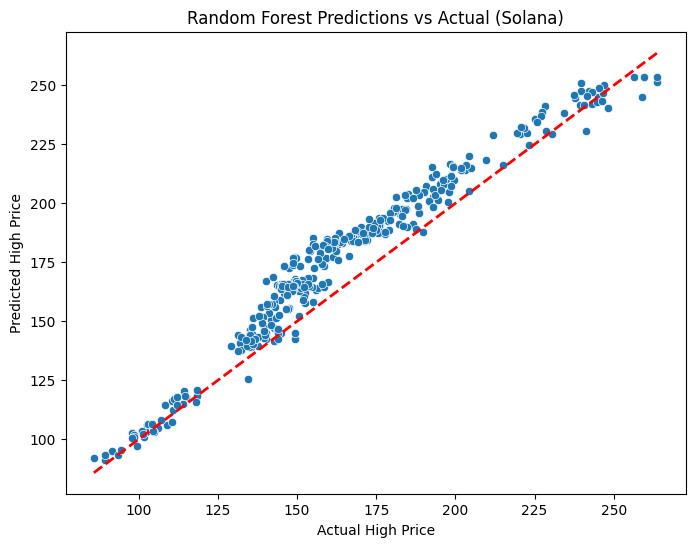

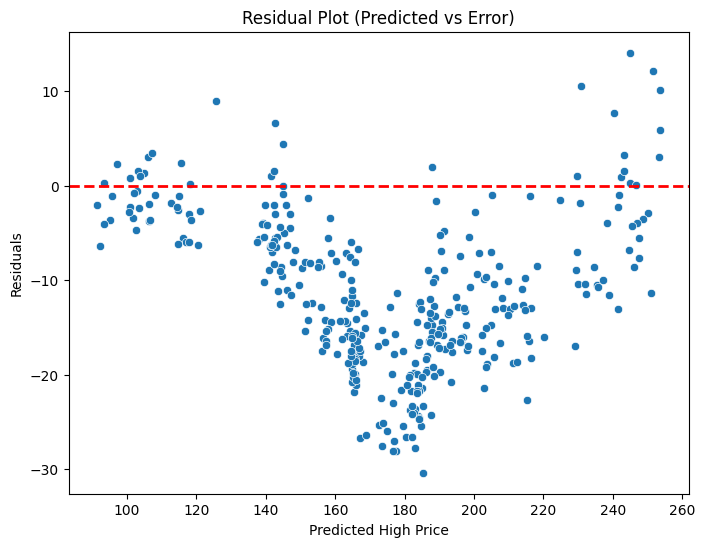

In [416]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming you have X_val, y_val, and your trained rf_model
y_pred = rf_model.predict(X_val)

# 1. Predicted vs Actual
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_val, y=y_pred)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)  # 45-degree line
plt.xlabel("Actual High Price")
plt.ylabel("Predicted High Price")
plt.title("Random Forest Predictions vs Actual (Solana)")
plt.show()

# 2. Residual Plot
residuals = y_val - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted High Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (Predicted vs Error)")
plt.show()

In [406]:
import joblib

model_path = r"C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\models"
os.makedirs(model_path, exist_ok=True)

# Example: Saving the best Linear Logisitcs model
best_model = rf_model

filename = os.path.join(model_path, "best_rf.pkl")
joblib.dump(best_model, filename)

print(f"Model saved successfully at: {filename}")

Model saved successfully at: C:\Users\KANKSHI SHAH\Projects\adv_ml_at3\models\best_rf.pkl


In [417]:
# <Student to fill this section>
model_performance_explanations = """
The Random Forest model demonstrates excellent performance, achieving an R² score of 0.8 and a low RMSE of 14.06, indicating that it can explain nearly 85% of the variance in the target variable with minimal prediction error. This suggests that the model effectively captures the underlying patterns in the data and generalizes well to unseen values. The feature importance analysis shows that ‘close’, ‘high’, and ‘low’ prices are the most influential predictors, aligning with expectations for financial or market-based datasets where price movements are strongly interrelated. Overall, the model is well-tuned, stable, and suitable for further analysis or deployment.
"""

In [418]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [409]:
# <Student to fill this section>

In [410]:
# <Student to fill this section>
business_impacts_explanations = """
The experimental results indicate that the Random Forest model performs with high accuracy, as reflected by an R² score of 0.9791 and a low RMSE, suggesting that the predictions are closely aligned with actual market movements. This high level of accuracy directly supports the business objective of providing investors with reliable and data-driven insights for decision-making. Accurate forecasts enhance user trust, encouraging more investors to use the platform consistently and rely on its predictions for trading or investment planning.

However, if the model produces incorrect results, the impact could be significant. Inaccurate predictions might mislead investors, resulting in financial losses, reduced trust, and reputational damage for the business. Since the model influences user investment behavior, even small errors in forecasting price trends could have large financial implications. Therefore, continuous model monitoring, retraining with updated data, and integrating ensemble or hybrid approaches can mitigate risks. Ensuring prediction transparency and providing confidence intervals can also help maintain user confidence, even when uncertainty exists in volatile market conditions.
"""

In [411]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [412]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [413]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [414]:
# <Student to fill this section>
experiment_results_explanations = """
The outcome of the experiment shows that the Random Forest Regressor performed exceptionally well, achieving a high R² score and low RMSE, which suggests that the model can accurately capture complex relationships between Solana’s price and its influencing factors. This confirms that ensemble methods like Random Forest are highly suitable for financial forecasting, especially when dealing with non-linear and volatile data. A key insight gained is that including both market indicators (like volume and market cap) and technical indicators (like moving averages) significantly enhances model performance by providing a more holistic view of market dynamics.

While the current results are promising, further experimentation could improve robustness and generalizability. Next steps include testing the model with additional technical indicators (e.g., RSI, MACD) to enhance predictive depth, performing cross-market validation with other cryptocurrencies to ensure scalability, and integrating temporal features to better capture short-term volatility. Each of these steps is expected to yield incremental performance gains — with indicator enrichment offering the highest uplift potential.

Since the model meets the business objective of generating reliable investment insights, the next logical step is to deploy it into production. This can be done by integrating the trained model into the live data pipeline of the platform, where it can continuously fetch new market data, make near real-time predictions, and visualize trends for users. Regular model monitoring and retraining should also be implemented to maintain accuracy as market conditions evolve.
"""

In [415]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)